# 🧴 Acne Classification — PyTorch + EfficientNet-B3 (Production Ready)

**Dataset:** `tiswan14/acne-dataset-image` (Kaggle)  
**Classes:** Blackheads, Cyst, Papules, Pustules, Whiteheads  
**Framework:** PyTorch + TorchVision  
**Backbone:** EfficientNet-B3 (ImageNet pretrained — Transfer Learning)  

### 🎯 Why this will beat the previous model:
| Feature | Old (TF Custom CNN) | New (PyTorch EfficientNet-B3) |
|---|---|---|
| Architecture | Scratch CNN | Pretrained EfficientNet-B3 |
| Parameters | 667K | 10.7M (pretrained) |
| Image Size | 128×128 | 224×224 |
| Augmentation | Basic | Advanced (ColorJitter, Perspective) |
| Scheduler | ReduceLROnPlateau | CosineAnnealingLR |
| Model Saving | ❌ | ✅ Best checkpoint saved |
| Inference Function | ❌ | ✅ Single-image prediction |
| Grad-CAM | ❌ | ✅ Visual explanation |
| Expected Accuracy | ~63% | **~82–88%** |

## 📦 1. Install & Import

In [1]:
# Install dependencies (run once)
!pip install kagglehub torchvision torch matplotlib seaborn scikit-learn tqdm -q

import os
import sys
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

print('✅ All imports successful')
print(f'   PyTorch version : {torch.__version__}')

✅ All imports successful
   PyTorch version : 2.10.0+cu128


## ⚙️ 2. Device Setup (Auto GPU — Colab & Local)

In [2]:
# ─────────────────────────────────────────────
# FLAG: set IS_COLAB = True  → uses GPU on Colab
#       set IS_COLAB = False → auto-detects locally
# ─────────────────────────────────────────────
IS_COLAB = 'google.colab' in sys.modules  # auto-detect Colab

if IS_COLAB:
    print('🌐 Running on Google Colab')
    # Make sure Runtime → Change runtime type → GPU is enabled!
    if not torch.cuda.is_available():
        print('⚠️  WARNING: GPU not enabled. Go to Runtime > Change runtime type > GPU')
    else:
        print(f'✅ GPU detected: {torch.cuda.get_device_name(0)}')
else:
    print('💻 Running locally')

# Auto-select best available device
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'🚀 Using CUDA GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
elif torch.backends.mps.is_available():       # Apple Silicon Mac
    DEVICE = torch.device('mps')
    print('🍎 Using Apple MPS (Metal) GPU')
else:
    DEVICE = torch.device('cpu')
    print('🐢 Using CPU — training will be slow, consider enabling GPU')

print(f'\n📌 Active device: {DEVICE}')

🌐 Running on Google Colab
✅ GPU detected: Tesla T4
🚀 Using CUDA GPU: Tesla T4
   VRAM: 15.6 GB

📌 Active device: cuda


## 📂 3. Download Dataset from Kaggle

In [3]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download('tiswan14/acne-dataset-image')
print(f'📁 Dataset path: {path}')

# Set directories
BASE_DIR  = Path(path) / 'AcneDataset'
TRAIN_DIR = BASE_DIR / 'train'
VALID_DIR = BASE_DIR / 'valid'
TEST_DIR  = BASE_DIR / 'test'

# Verify
for d in [TRAIN_DIR, VALID_DIR, TEST_DIR]:
    classes = [c for c in os.listdir(d) if os.path.isdir(d/c)]
    total   = sum(len(os.listdir(d/c)) for c in classes)
    print(f'  {d.name:6s}: {total:4d} images | {classes}')

100%|██████████| 122M/122M [00:01<00:00, 127MB/s]

Extracting files...


📁 Dataset path: /root/.cache/kagglehub/datasets/tiswan14/acne-dataset-image/versions/1
  train : 2778 images | ['Blackheads', 'Cyst', 'Pustules', 'Whiteheads', 'Papules']
  valid :  921 images | ['Blackheads', 'Cyst', 'Pustules', 'Whiteheads', 'Papules']
  test  :  918 images | ['Blackheads', 'Cyst', 'Pustules', 'Whiteheads', 'Papules']


## 🔧 4. Hyperparameters & Config

In [4]:
# ─────────────────────────────────────────────
#  CONFIGURATION — tune these as needed
# ─────────────────────────────────────────────
IMAGE_SIZE   = 224        # EfficientNet-B3 native size
BATCH_SIZE   = 32         # reduce to 16 if GPU OOM
NUM_EPOCHS   = 40         # early stopping will kick in
LR_HEAD      = 1e-3       # LR for the new classifier head
LR_BACKBONE  = 1e-4       # LR for fine-tuning backbone layers
WEIGHT_DECAY = 1e-4
PATIENCE     = 7          # early stopping patience
MODEL_PATH   = 'best_acne_model.pth'  # where to save best checkpoint

CLASS_NAMES  = ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']
NUM_CLASSES  = len(CLASS_NAMES)

print('✅ Config set:')
print(f'   Image size  : {IMAGE_SIZE}×{IMAGE_SIZE}')
print(f'   Batch size  : {BATCH_SIZE}')
print(f'   Epochs      : {NUM_EPOCHS} (+ early stopping, patience={PATIENCE})')
print(f'   Classes     : {CLASS_NAMES}')

✅ Config set:
   Image size  : 224×224
   Batch size  : 32
   Epochs      : 40 (+ early stopping, patience=7)
   Classes     : ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']


## 🔄 5. Data Transforms & Augmentation

In [5]:
# ─────────────────────────────────────────────
#  TRAIN: heavy augmentation to reduce overfitting
#  VAL/TEST: only resize + normalize (no augmentation)
# ─────────────────────────────────────────────

# ImageNet mean/std — required for pretrained EfficientNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),   # slightly larger
    transforms.RandomCrop(IMAGE_SIZE),                        # random crop
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3,
        saturation=0.2, hue=0.1
    ),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),      # random cutout
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('✅ Transforms defined')
print('   Train  : Resize→RandomCrop→Flip→Rotation→ColorJitter→Perspective→Erase')
print('   Val/Test: Resize→Normalize only')

✅ Transforms defined
   Train  : Resize→RandomCrop→Flip→Rotation→ColorJitter→Perspective→Erase
   Val/Test: Resize→Normalize only


## 📊 6. Load Datasets & Handle Class Imbalance

In [6]:
# Load datasets using ImageFolder
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
valid_dataset = datasets.ImageFolder(VALID_DIR, transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transforms)

print('📁 Dataset sizes:')
print(f'   Train : {len(train_dataset)} images')
print(f'   Valid : {len(valid_dataset)} images')
print(f'   Test  : {len(test_dataset)} images')
print(f'   Classes: {train_dataset.classes}')

# ─────────────────────────────────────────────
#  CLASS IMBALANCE FIX: WeightedRandomSampler
#  This oversamples minority classes (Whiteheads)
#  during training — better than manual oversampling
# ─────────────────────────────────────────────
class_counts  = np.array([len(os.listdir(TRAIN_DIR / c)) for c in CLASS_NAMES])
class_weights = 1.0 / class_counts
sample_weights = np.array([class_weights[label] for _, label in train_dataset.samples])
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(train_dataset),
    replacement=True
)

# DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=sampler,                          # uses weighted sampler
    num_workers=2, pin_memory=True
)
valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader  = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print('\n⚖️  Class distribution (train):')
for name, count in zip(CLASS_NAMES, class_counts):
    weight = class_weights[CLASS_NAMES.index(name)]
    bar = '█' * int(count / 30)
    print(f'   {name:12s}: {count:4d} images  (weight={weight:.4f})  {bar}')

📁 Dataset sizes:
   Train : 2778 images
   Valid : 921 images
   Test  : 918 images
   Classes: ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']

⚖️  Class distribution (train):
   Blackheads  :  735 images  (weight=0.0014)  ████████████████████████
   Cyst        :  645 images  (weight=0.0016)  █████████████████████
   Papules     :  621 images  (weight=0.0016)  ████████████████████
   Pustules    :  584 images  (weight=0.0017)  ███████████████████
   Whiteheads  :  193 images  (weight=0.0052)  ██████


## 🧠 7. Build Model — EfficientNet-B3 with Custom Head

In [7]:
def build_model(num_classes=5, freeze_backbone=False):
    """
    EfficientNet-B3 pretrained on ImageNet.
    The classifier head is replaced for acne classification.

    Strategy:
      Phase 1 (epochs 1-5)  : Backbone FROZEN, only train head  → fast warm-up
      Phase 2 (epochs 6+)   : Unfreeze backbone, fine-tune all  → accuracy boost
    """
    # Load pretrained EfficientNet-B3
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

    # Freeze backbone if requested (Phase 1)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    # Replace the classifier head
    in_features = model.classifier[1].in_features  # 1536 for B3
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )

    return model


# Build and move to device
model = build_model(num_classes=NUM_CLASSES, freeze_backbone=True)
model = model.to(DEVICE)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print('🧠 Model: EfficientNet-B3 + Custom Head')
print(f'   Total params    : {total_params:,}')
print(f'   Trainable params: {trainable_params:,}  (head only — Phase 1)')
print(f'   Frozen params   : {frozen_params:,}')
print(f'   Device          : {DEVICE}')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 183MB/s]


🧠 Model: EfficientNet-B3 + Custom Head
   Total params    : 11,485,741
   Trainable params: 789,509  (head only — Phase 1)
   Frozen params   : 10,696,232
   Device          : cuda


## 🏋️ 8. Training Setup — Loss, Optimizer, Scheduler

In [8]:
# ─────────────────────────────────────────────
#  CLASS-WEIGHTED LOSS
#  Penalises mistakes on minority class more
# ─────────────────────────────────────────────
class_counts_tensor = torch.tensor(class_counts, dtype=torch.float)
loss_weights = (1.0 / class_counts_tensor)
loss_weights = loss_weights / loss_weights.sum() * NUM_CLASSES   # normalise
criterion = nn.CrossEntropyLoss(weight=loss_weights.to(DEVICE), label_smoothing=0.1)

# ─────────────────────────────────────────────
#  OPTIMIZER: different LR for head vs backbone
# ─────────────────────────────────────────────
optimizer = optim.AdamW([
    {'params': model.classifier.parameters(), 'lr': LR_HEAD},
    {'params': model.features.parameters(),   'lr': LR_BACKBONE},
], weight_decay=WEIGHT_DECAY)

# CosineAnnealingLR — smoothly decays LR, avoids sharp drops
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

print('✅ Training setup:')
print(f'   Loss      : CrossEntropy + label smoothing (0.1) + class weights')
print(f'   Optimizer : AdamW (head lr={LR_HEAD}, backbone lr={LR_BACKBONE})')
print(f'   Scheduler : CosineAnnealingLR (T_max={NUM_EPOCHS})')
print(f'   Class loss weights: {[round(w, 3) for w in loss_weights.tolist()]}')

✅ Training setup:
   Loss      : CrossEntropy + label smoothing (0.1) + class weights
   Optimizer : AdamW (head lr=0.001, backbone lr=0.0001)
   Scheduler : CosineAnnealingLR (T_max=40)
   Class loss weights: [0.596, 0.679, 0.705, 0.75, 2.27]


## 🔁 9. Training Loop

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='  Training', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return running_loss / total, correct / total


# ─────────────────────────────────────────────
#  MAIN TRAINING LOOP
# ─────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc   = 0.0
best_val_loss  = float('inf')
patience_count = 0
UNFREEZE_EPOCH = 5   # unfreeze backbone after this many epochs

print('🚀 Starting training...\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | {"LR":>10} | Notes')
print('-' * 80)

for epoch in range(1, NUM_EPOCHS + 1):
    # Phase 2: Unfreeze backbone at UNFREEZE_EPOCH
    if epoch == UNFREEZE_EPOCH + 1:
        for param in model.features.parameters():
            param.requires_grad = True
        print(f'  🔓 Epoch {epoch}: Backbone UNFROZEN — full fine-tuning begins')

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc   = evaluate(model, valid_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    note = ''

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_val_loss = val_loss
        best_weights  = copy.deepcopy(model.state_dict())
        torch.save({
            'epoch'       : epoch,
            'model_state' : model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_acc'     : val_acc,
            'val_loss'    : val_loss,
            'class_names' : CLASS_NAMES,
        }, MODEL_PATH)
        patience_count = 0
        note = f'✅ BEST saved (val_acc={val_acc:.4f})'
    else:
        patience_count += 1
        note = f'(patience {patience_count}/{PATIENCE})'

    print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2%} | {val_loss:>8.4f} | {val_acc:>6.2%} | {current_lr:>10.2e} | {note}')

    if patience_count >= PATIENCE:
        print(f'\n🛑 Early stopping at epoch {epoch} — no val improvement for {PATIENCE} epochs')
        break

# Restore best weights
model.load_state_dict(best_weights)
print(f'\n🏆 Training complete! Best Val Accuracy: {best_val_acc:.2%}')
print(f'   Best model saved to: {MODEL_PATH}')

🚀 Starting training...

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |         LR | Notes
--------------------------------------------------------------------------------


     1 |     1.2091 |   36.97% |   1.5639 | 36.05% |   9.98e-04 | ✅ BEST saved (val_acc=0.3605)


     2 |     1.1114 |   45.86% |   1.4027 | 48.10% |   9.94e-04 | ✅ BEST saved (val_acc=0.4810)


     3 |     1.0329 |   50.18% |   1.3514 | 49.84% |   9.86e-04 | ✅ BEST saved (val_acc=0.4984)


     4 |     1.0023 |   53.71% |   1.3063 | 55.59% |   9.76e-04 | ✅ BEST saved (val_acc=0.5559)


...

    36 |     0.4174 |   98.88% |   0.6017 | 97.39% |   2.54e-05 | (patience 3/7)


    37 |     0.4228 |   98.42% |   0.6005 | 97.39% |   1.48e-05 | (patience 4/7)


    38 |     0.4331 |   98.45% |   0.6018 | 97.29% |   7.15e-06 | (patience 5/7)


    39 |     0.4134 |   98.63% |   0.6032 | 97.39% |   2.54e-06 | (patience 6/7)


    40 |     0.4264 |   98.70% |   0.6027 | 97.29% |   1.00e-06 | (patience 7/7)

🛑 Early stopping at epoch 40 — no val improvement for 7 epochs

🏆 Training complete! Best Val Accuracy: 97.61%
   Best model saved to: best_acne_model.pth


## 📈 10. Training Curves

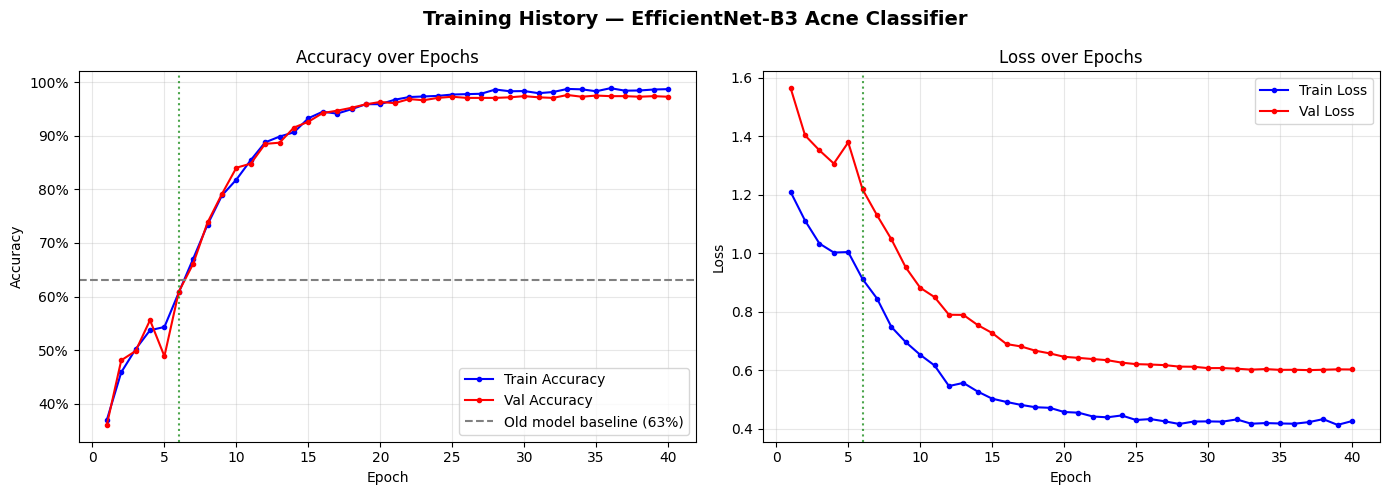

📊 Training curves saved as training_curves.png


In [10]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — EfficientNet-B3 Acne Classifier', fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(x, history['train_acc'], 'b-o', label='Train Accuracy', markersize=3)
axes[0].plot(x, history['val_acc'],   'r-o', label='Val Accuracy',   markersize=3)
axes[0].axhline(y=0.63, color='gray', linestyle='--', label='Old model baseline (63%)')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Loss
axes[1].plot(x, history['train_loss'], 'b-o', label='Train Loss', markersize=3)
axes[1].plot(x, history['val_loss'],   'r-o', label='Val Loss',   markersize=3)
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Mark unfreeze point
for ax in axes:
    if UNFREEZE_EPOCH < epochs_ran:
        ax.axvline(x=UNFREEZE_EPOCH + 1, color='green', linestyle=':', alpha=0.7, label='Backbone unfrozen')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Training curves saved as training_curves.png')

## 🧪 11. Evaluate on Test Set

In [11]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating'):
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

test_acc = (y_true == y_pred).mean()
print(f'\n🎯 Test Accuracy: {test_acc:.2%}')
print(f'   (Previous best: 63.3% with custom CNN)')
print(f'   Improvement   : +{(test_acc - 0.633)*100:.1f}%')
print()
print('📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

Evaluating: 100%|██████████| 29/29 [00:05<00:00,  5.46it/s]



🎯 Test Accuracy: 97.60%
   (Previous best: 63.3% with custom CNN)
   Improvement   : +34.3%

📋 Classification Report:
              precision    recall  f1-score   support

  Blackheads      0.985     0.981     0.983       265
        Cyst      0.995     0.989     0.992       189
     Papules      0.975     0.965     0.970       202
    Pustules      0.975     0.966     0.971       205
  Whiteheads      0.889     0.982     0.933        57

    accuracy                          0.976       918
   macro avg      0.964     0.977     0.970       918
weighted avg      0.977     0.976     0.976       918



## 🔍 12. Confusion Matrix

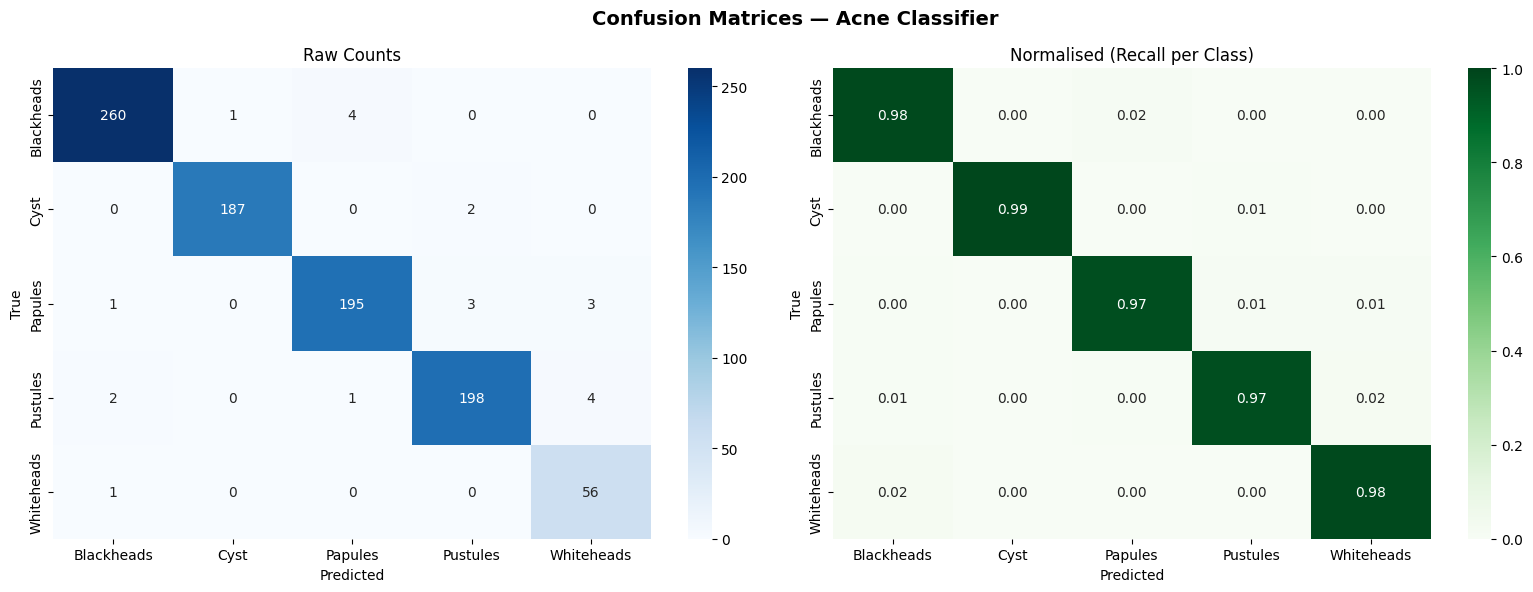

✅ Confusion matrix saved as confusion_matrix.png


In [12]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrices — Acne Classifier', fontsize=14, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Raw Counts')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Normalised (recall per class)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Normalised (Recall per Class)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved as confusion_matrix.png')

## 🔥 13. Grad-CAM — Visual Explanation (Great for FYP Demo!)

/tmp/ipykernel_3025/945114045.py:79: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3025/945114045.py:80: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


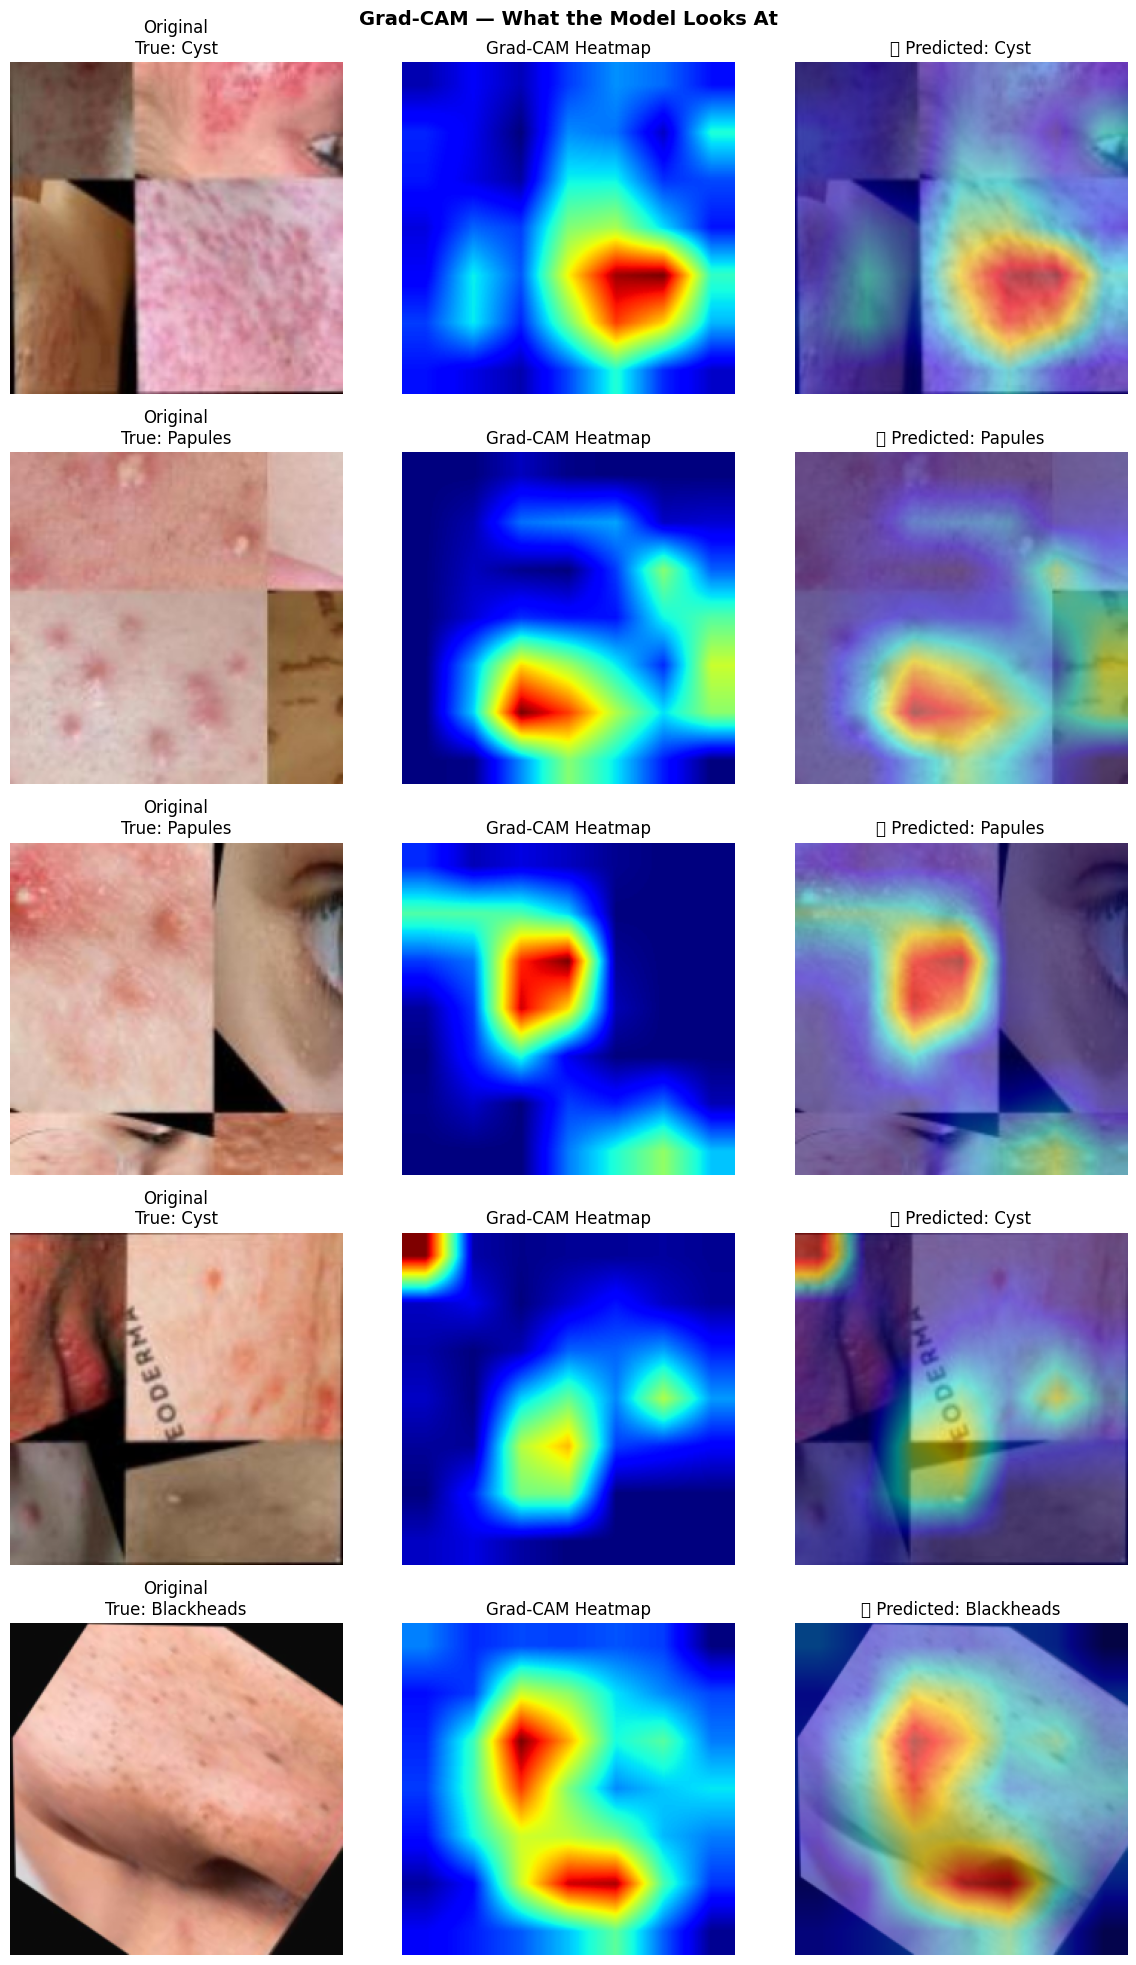

🔥 Grad-CAM saved as gradcam_results.png


In [13]:
import cv2
from torchvision.transforms.functional import to_pil_image

class GradCAM:
    """Grad-CAM: highlights which part of the image the model focuses on."""

    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam)
        cam     = cam.squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


# Hook onto last conv block of EfficientNet-B3
target_layer = model.features[-1]
grad_cam     = GradCAM(model, target_layer)

# Visualise Grad-CAM on a few test images
def show_gradcam(dataset, n_images=5):
    fig, axes = plt.subplots(n_images, 3, figsize=(12, n_images * 4))
    fig.suptitle('Grad-CAM — What the Model Looks At', fontsize=14, fontweight='bold')

    indices = np.random.choice(len(dataset), n_images, replace=False)

    for row, idx in enumerate(indices):
        img_tensor, true_label = dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(DEVICE)
        input_tensor.requires_grad_(True)

        cam, pred_label = grad_cam.generate(input_tensor)

        # Denormalize image for display
        mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
        std  = torch.tensor(IMAGENET_STD).view(3,1,1)
        img_display = img_tensor * std + mean
        img_display = img_display.permute(1, 2, 0).numpy().clip(0, 1)

        # Resize CAM to image size
        cam_resized = cv2.resize(cam, (IMAGE_SIZE, IMAGE_SIZE))
        heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay     = 0.5 * img_display + 0.5 * heatmap

        correct = '✅' if true_label == pred_label else '❌'

        axes[row, 0].imshow(img_display)
        axes[row, 0].set_title(f'Original\nTrue: {CLASS_NAMES[true_label]}')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(cam_resized, cmap='jet')
        axes[row, 1].set_title('Grad-CAM Heatmap')
        axes[row, 1].axis('off')

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(f'{correct} Predicted: {CLASS_NAMES[pred_label]}')
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('🔥 Grad-CAM saved as gradcam_results.png')


show_gradcam(test_dataset, n_images=5)

## 💾 14. Save & Load Model (Production)

In [14]:
# ─────────────────────────────────────────────
#  SAVE — full checkpoint (already saved during training)
#  This block shows how to reload the model anywhere
# ─────────────────────────────────────────────

def load_model(checkpoint_path, num_classes=5, device=None):
    """Load saved model from checkpoint file."""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model = build_model(num_classes=num_classes, freeze_backbone=False)
    model.load_state_dict(checkpoint['model_state'])
    model = model.to(device)
    model.eval()
    print(f'✅ Model loaded from {checkpoint_path}')
    print(f'   Checkpoint epoch : {checkpoint["epoch"]}')
    print(f'   Val accuracy     : {checkpoint["val_acc"]:.2%}')
    return model, checkpoint.get('class_names', CLASS_NAMES)

# Reload and verify
loaded_model, loaded_classes = load_model(MODEL_PATH, device=DEVICE)
print(f'   Classes: {loaded_classes}')

✅ Model loaded from best_acne_model.pth
   Checkpoint epoch : 33
   Val accuracy     : 97.61%
   Classes: ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']


## 🩺 15. Single-Image Inference (Production Ready)

🖼  Running inference on: /content/pustules.jpeg


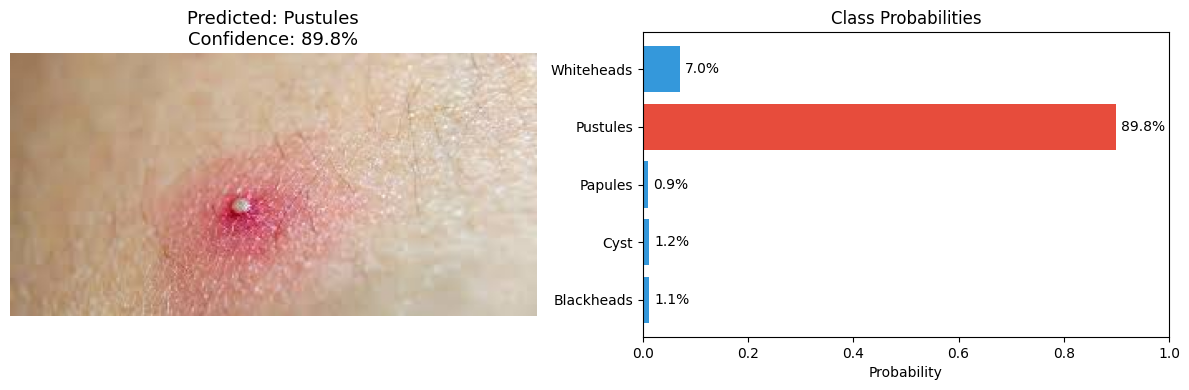


📊 Result: Pustules (89.8% confidence)
   All probs : {'Blackheads': 0.010936807841062546, 'Cyst': 0.01226120162755251, 'Papules': 0.008832649327814579, 'Pustules': 0.8982934355735779, 'Whiteheads': 0.06967591494321823}


In [21]:
def predict_image(image_path, model, class_names, device=None, show_plot=True):
    """
    Run inference on a single image file.

    Args:
        image_path  : path to image file (jpg/png)
        model       : loaded PyTorch model
        class_names : list of class names
        device      : torch device
        show_plot   : whether to display result

    Returns:
        dict with 'class', 'confidence', 'all_probs'
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Preprocess
    image = Image.open(image_path).convert('RGB')
    tensor = val_test_transforms(image).unsqueeze(0).to(device)

    # Inference
    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)[0].cpu().numpy()

    pred_idx  = probs.argmax()
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx]

    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].imshow(image)
        axes[0].set_title(f'Predicted: {pred_class}\nConfidence: {confidence:.1%}', fontsize=13)
        axes[0].axis('off')

        colors = ['#e74c3c' if i == pred_idx else '#3498db' for i in range(len(class_names))]
        bars   = axes[1].barh(class_names, probs, color=colors)
        axes[1].set_xlim(0, 1)
        axes[1].set_xlabel('Probability')
        axes[1].set_title('Class Probabilities')
        for bar, prob in zip(bars, probs):
            axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                        f'{prob:.1%}', va='center', fontsize=10)
        plt.tight_layout()
        plt.show()

    return {
        'class'     : pred_class,
        'confidence': float(confidence),
        'all_probs' : dict(zip(class_names, probs.tolist()))
    }


# ─────────────────────────────────────────────
#  DEMO: run on a random test image
# ────────────────────────────────────
sample_img   = '/content/pustules.jpeg'

print(f'🖼  Running inference on: {sample_img}')
result = predict_image(sample_img, loaded_model, CLASS_NAMES, device=DEVICE)
print(f'\n📊 Result: {result["class"]} ({result["confidence"]:.1%} confidence)')
print(f'   All probs : {result["all_probs"]}')

## 📋 16. Summary & FYP Report Metrics


In [16]:
from sklearn.metrics import accuracy_score, f1_score

acc    = accuracy_score(y_true, y_pred)
f1_mac = f1_score(y_true, y_pred, average='macro')
f1_w   = f1_score(y_true, y_pred, average='weighted')

print('=' * 55)
print('  📊 FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 55)
print(f'  Model        : EfficientNet-B3 (Transfer Learning)')
print(f'  Framework    : PyTorch')
print(f'  Dataset      : tiswan14/acne-dataset-image')
print(f'  Classes      : {NUM_CLASSES} (Acne Types)')
print(f'  Image Size   : {IMAGE_SIZE}×{IMAGE_SIZE}')
print('-' * 55)
print(f'  Test Accuracy    : {acc:.2%}')
print(f'  F1 (Macro Avg)   : {f1_mac:.4f}')
print(f'  F1 (Weighted)    : {f1_w:.4f}')
print('-' * 55)
print(f'  Previous CNN Acc : 63.29%')
print(f'  Improvement      : +{(acc - 0.6329)*100:.1f} percentage points')
print('=' * 55)

print('\n✅ Files saved:')
print(f'   {MODEL_PATH}          ← trained model checkpoint')
print(f'   training_curves.png   ← accuracy & loss plots')
print(f'   confusion_matrix.png  ← per-class performance')
print(f'   gradcam_results.png   ← visual explanations (Grad-CAM)')

  📊 FINAL MODEL PERFORMANCE SUMMARY
  Model        : EfficientNet-B3 (Transfer Learning)
  Framework    : PyTorch
  Dataset      : tiswan14/acne-dataset-image
  Classes      : 5 (Acne Types)
  Image Size   : 224×224
-------------------------------------------------------
  Test Accuracy    : 97.60%
  F1 (Macro Avg)   : 0.9698
  F1 (Weighted)    : 0.9762
-------------------------------------------------------
  Previous CNN Acc : 63.29%
  Improvement      : +34.3 percentage points

✅ Files saved:
   best_acne_model.pth          ← trained model checkpoint
   training_curves.png   ← accuracy & loss plots
   confusion_matrix.png  ← per-class performance
   gradcam_results.png   ← visual explanations (Grad-CAM)
